<a href="https://colab.research.google.com/github/honeykgarg/PyTorch_NN/blob/regression_with_regularization/RegressionUsingNNLayersAndOptimizers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt


In [2]:
x_train = np.array([[4.7], [2.4], [7.5], [7.1], [4.3],
                    [7.8], [8.9], [5.2], [4.59], [2.1],
                    [8], [5], [7.5], [5], [4],
                    [8], [5.2], [4.9], [3], [4.7],
                    [4], [4.8], [3.5], [2.1], [4.1]],
                   dtype = np.float32)

y_train = np.array([[2.6], [1.6], [3.09], [2.4], [2.4],
                    [3.3], [2.6], [1.96], [3.13], [1.76],
                    [3.2], [2.1], [1.6], [2.5], [2.2],
                    [2.75], [2.4], [1.8], [1], [2],
                    [1.6], [2.4], [2.6], [1.5], [3.1]],
                   dtype = np.float32)


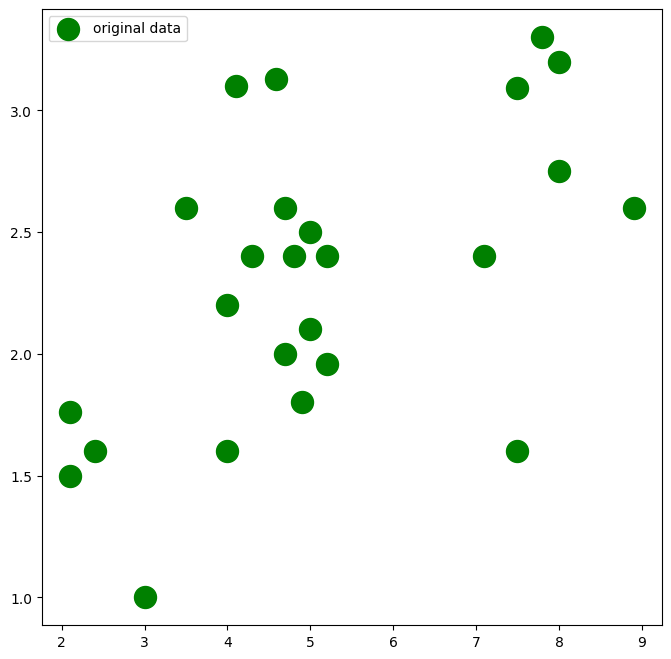

In [3]:
plt.figure(figsize=(8,8))
plt.scatter(x_train, y_train, label = 'original data', s=250, c='g')
plt.legend()
plt.show()

In [4]:
X_train = torch.from_numpy(x_train)
Y_train = torch.from_numpy(y_train)

In [5]:
X_train.size()

torch.Size([25, 1])

In [7]:
inp = 1
hidden = 5
out = 1

In [8]:
model = torch.nn.Sequential(torch.nn.Linear(inp, hidden),
                            torch.nn.ReLU(), torch.nn.Linear(hidden, out))

In [9]:
loss_function = torch.nn.MSELoss(reduction = 'sum')

In [17]:
learning_rate = 1e-4

optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)

for i in range(500):
  y_pred = model(X_train)

  loss = loss_function(y_pred, Y_train)
  print(i, loss.item())

  model.zero_grad()
  loss.backward()

  optimizer.step()


0 6.681521892547607
1 6.680090427398682
2 6.67866325378418
3 6.677238941192627
4 6.675817966461182
5 6.6743974685668945
6 6.672982215881348
7 6.671570301055908
8 6.670161247253418
9 6.6687541007995605
10 6.667351722717285
11 6.665951251983643
12 6.664554595947266
13 6.6631598472595215
14 6.661769866943359
15 6.660382270812988
16 6.658997058868408
17 6.6576151847839355
18 6.656235694885254
19 6.65485954284668
20 6.653487682342529
21 6.652117729187012
22 6.650750160217285
23 6.649386882781982
24 6.6480255126953125
25 6.64666748046875
26 6.645312309265137
27 6.6439619064331055
28 6.642611503601074
29 6.641264915466309
30 6.639923095703125
31 6.638581275939941
32 6.63724422454834
33 6.635909557342529
34 6.634579181671143
35 6.633250713348389
36 6.631925106048584
37 6.63060188293457
38 6.629281997680664
39 6.627965450286865
40 6.626651287078857
41 6.625340938568115
42 6.624032497406006
43 6.622727394104004
44 6.621425151824951
45 6.620124816894531
46 6.61883020401001
47 6.617536544799805
48

In [18]:
predicted_tensor = model(X_train)
predicted_tensor


tensor([[2.1897],
        [1.7005],
        [2.7851],
        [2.7001],
        [2.1046],
        [2.8490],
        [3.0829],
        [2.2960],
        [2.1663],
        [1.6367],
        [2.8915],
        [2.2535],
        [2.7851],
        [2.2535],
        [2.0408],
        [2.8915],
        [2.2960],
        [2.2322],
        [1.8281],
        [2.1897],
        [2.0408],
        [2.2109],
        [1.9344],
        [1.6367],
        [2.0621]], grad_fn=<AddmmBackward0>)

In [19]:
predicted = predicted_tensor.detach().numpy()

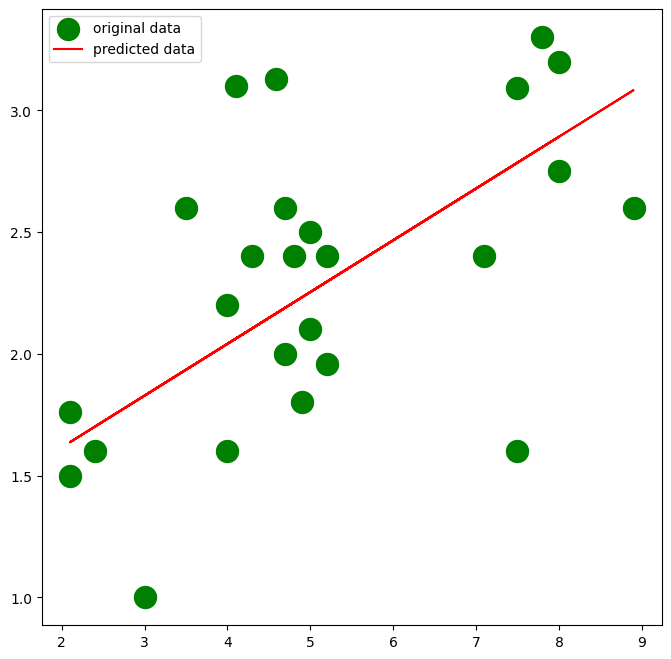

In [20]:
plt.figure(figsize=(8,8))
plt.scatter(x_train, y_train, label = 'original data', s=250, c='g')
plt.plot(x_train, predicted, label = 'predicted data', c='r')
plt.legend()
plt.show()